In [37]:
from pathlib import Path
import numpy as np
from PIL import Image

# --- ML --- #
import tensorflow as tf
from keras import Sequential, Input
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from keras.optimizers import SGD
from keras.losses import SparseCategoricalCrossentropy
from keras.metrics import SparseCategoricalAccuracy, F1Score

In [38]:
raw_dataset_path = Path("./wikiart")

# Compute number of classes
num_classes = sum(1 for item in raw_dataset_path.iterdir() if item.is_dir())

shapes = set()

# Compute image dimensions and verify shape consistency across the dataset
for artist_dir in raw_dataset_path.iterdir():
    for img_path in artist_dir.glob("*.jpg"):
        img = np.array(Image.open(img_path))
        shapes.add(img.shape)

print(f"Number of classes: {num_classes}")
print(f"{shapes} -> (height, width, channels)")

Number of classes: 23
{(512, 512, 3)} -> (height, width, channels)


In [40]:
dataset_path = Path("./data")

# --- Load splits --- #
train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path / "train",
    image_size=(224, 224),
    batch_size=32,
    shuffle=True,
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path / "validation",
    image_size=(224, 224),
    batch_size=32,
    shuffle=False,
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path / "test",
    image_size=(224, 224),
    batch_size=32,
    shuffle=False,
)

# --- Inspect class mapping --- #
class_names = train_dataset.class_names
class_to_idx = {name: i for i, name in enumerate(class_names)}

# --- Normalize datasets --- #
train_dataset = train_dataset.map(lambda x, y: (x / 255.0, y))
validation_dataset = validation_dataset.map(lambda x, y: (x / 255.0, y))
test_dataset = test_dataset.map(lambda x, y: (x / 255.0, y))


print("Class mapping:", class_to_idx)

# Inspect first batch
for images, labels in train_dataset.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)


Found 9326 files belonging to 23 classes.
Found 1992 files belonging to 23 classes.
Found 2022 files belonging to 23 classes.
Class mapping: {'Albrecht_Durer': 0, 'Boris_Kustodiev': 1, 'Camille_Pissarro': 2, 'Childe_Hassam': 3, 'Claude_Monet': 4, 'Edgar_Degas': 5, 'Eugene_Boudin': 6, 'Gustave_Dore': 7, 'Ilya_Repin': 8, 'Ivan_Aivazovsky': 9, 'Ivan_Shishkin': 10, 'John_Singer_Sargent': 11, 'Marc_Chagall': 12, 'Martiros_Saryan': 13, 'Nicholas_Roerich': 14, 'Pablo_Picasso': 15, 'Paul_Cezanne': 16, 'Pierre_Auguste_Renoir': 17, 'Pyotr_Konchalovsky': 18, 'Raphael_Kirchner': 19, 'Rembrandt': 20, 'Salvador_Dali': 21, 'Vincent_van_Gogh': 22}
Images shape: (32, 224, 224, 3)
Labels shape: (32,)


In [41]:
# --- CNN Architecture --- #
model = Sequential(
    layers=[
        Input(shape=(224 ,224, 3)),
        Conv2D(filters=3 * 8, kernel_size=(3, 3), activation="relu"),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(filters=3 * 16, kernel_size=(3, 3), activation="relu"),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten(),
        # input size is infered
        Dense(num_classes, activation="softmax"),
    ],
    name="first_CNN",
)

model.summary()

# Loss & Gradient
optimizer = SGD(learning_rate=0.01, name="optimizer")
loss = SparseCategoricalCrossentropy(name="loss")

# Evaluation metrics
categorical_accuracy = SparseCategoricalAccuracy(name="accuracy")

model.compile(optimizer=optimizer, loss=loss, metrics=[categorical_accuracy])

Model: "first_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 222, 222, 24)   │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 111, 111, 24)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 109, 109, 48)   │        10,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 54, 54, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 139968)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 23)             │     3,219,287 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,230,375 (12.32 MB)

 Trainable params: 3,230,375 (12.32 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
epochs = 20
history = model.fit(train_dataset, validation_data=validation_dataset, epochs=epochs)

Epoch 1/20
292/292 ━━━━━━━━━━━━━━━━━━━━ 54s 186ms/step - accuracy: 0.1825 - loss: 2.8140 - val_accuracy: 0.2179 - val_loss: 2.7298
Epoch 2/20
292/292 ━━━━━━━━━━━━━━━━━━━━ 56s 192ms/step - accuracy: 0.2671 - loss: 2.5153 - val_accuracy: 0.2620 - val_loss: 2.5040
Epoch 3/20
292/292 ━━━━━━━━━━━━━━━━━━━━ 57s 196ms/step - accuracy: 0.3191 - loss: 2.3238 - val_accuracy: 0.2023 - val_loss: 2.8194
Epoch 4/20
292/292 ━━━━━━━━━━━━━━━━━━━━ 59s 200ms/step - accuracy: 0.3641 - loss: 2.1731 - val_accuracy: 0.2932 - val_loss: 2.4807
Epoch 5/20
292/292 ━━━━━━━━━━━━━━━━━━━━ 62s 211ms/step - accuracy: 0.4050 - loss: 2.0186 - val_accuracy: 0.2641 - val_loss: 2.4998
Epoch 6/20
292/292 ━━━━━━━━━━━━━━━━━━━━ 66s 224ms/step - accuracy: 0.4612 - loss: 1.8392 - val_accuracy: 0.3384 - val_loss: 2.3557
Epoch 7/20
292/292 ━━━━━━━━━━━━━━━━━━━━ 64s 217ms/step - accuracy: 0.5305 - loss: 1.6129 - val_accuracy: 0.3193 - val_loss: 2.5125
Epoch 8/20
292/292 ━━━━━━━━━━━━━━━━━━━━ 65s 221ms/step - accuracy: 0.6051 - loss: 1

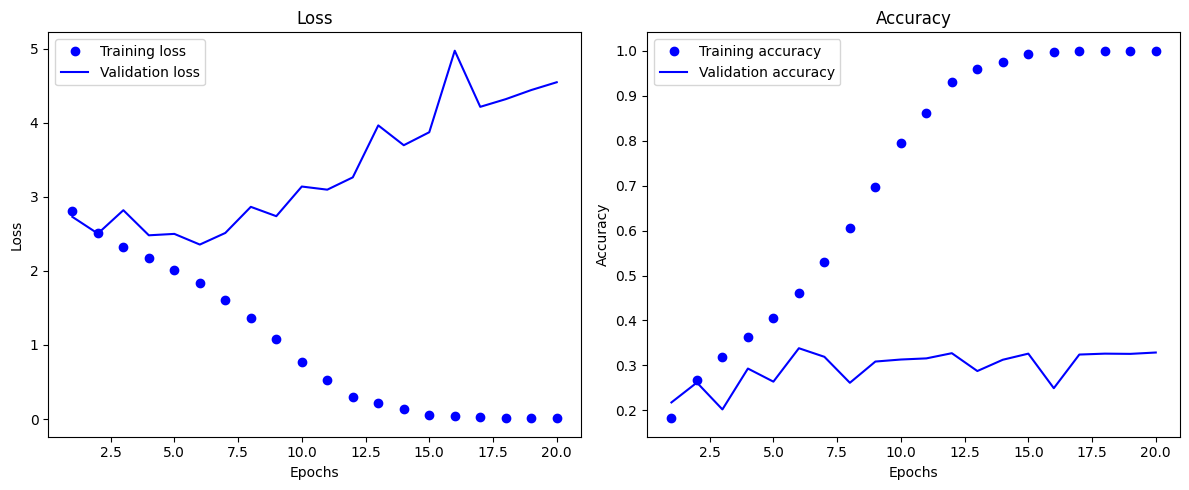

In [46]:
import matplotlib.pyplot as plt
history_dict = history.history

# Loss metrics
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
# Accuracy metrics
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]

epochs = range(1, len(loss_values) + 1)

plt.figure(figsize=(12, 5))

# Loss subplot
plt.subplot(1, 2, 1)
plt.plot(epochs, loss_values, "bo", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Accuracy subplot
plt.subplot(1, 2, 2)
plt.plot(epochs, acc, "bo", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


In [47]:
model.evaluate(test_dataset, return_dict=True, verbose=0)


{'accuracy': 0.32443127036094666, 'loss': 4.516812801361084}